
#Lab 7: Fast Fourier Transform (FFT)

 **Exercise** : Chord - musical sound: Do mayor

![Do mayor](https://upload.wikimedia.org/wikipedia/commons/7/79/Major_chord_on_C.png)




Load the Nota_CM_piano.mp3 file from a Do mayor sound:
1. Do the FFT using scipy and Numpy rutines (see notebook)
2. Used the rutine created in class `FT(x,y)`. Modify it and do the FT to the signal. Do you get the same results?

#Scipy and Numpy

In [2]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy import interpolate
import pandas as pd
from scipy.signal import find_peaks
import scipy.integrate as integrate

In [5]:
# Load the mp3 file
# sr=None preserves the original sampling rate; otherwise, it defaults to 22050 Hz
signal, sr = librosa.load('Nota_CM_piano.mp3', sr=None)

print(f"Sample Rate: {sr}")
print(f"Signal Shape: {signal.shape}")

Sample Rate: 44100
Signal Shape: (152064,)


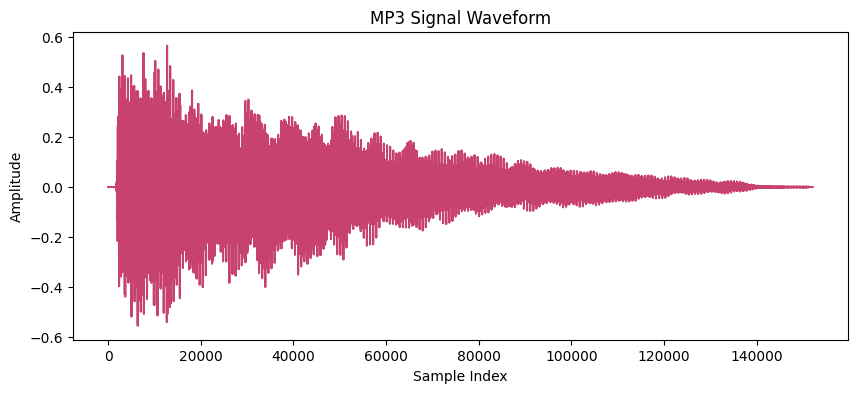

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(signal, c = "#C7426E")
plt.title("MP3 Signal Waveform")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

In [7]:
# 2. Compute the Fourier Transform
N = len(signal)
yf = fft(signal)
xf = fftfreq(N, 1/sr)

xf = xf[:N//2]
yf = np.abs(yf[:N//2])

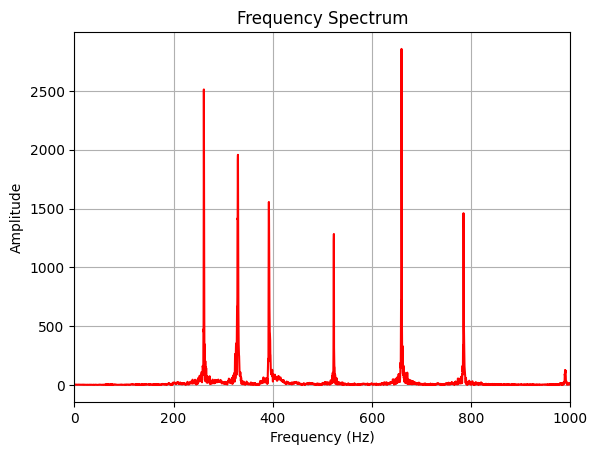

In [8]:
# 3. Plot the magnitude spectrum
plt.plot(xf, np.abs(yf), c="red") # Plot positive frequencies only
plt.title('Frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0,1000)
plt.grid()

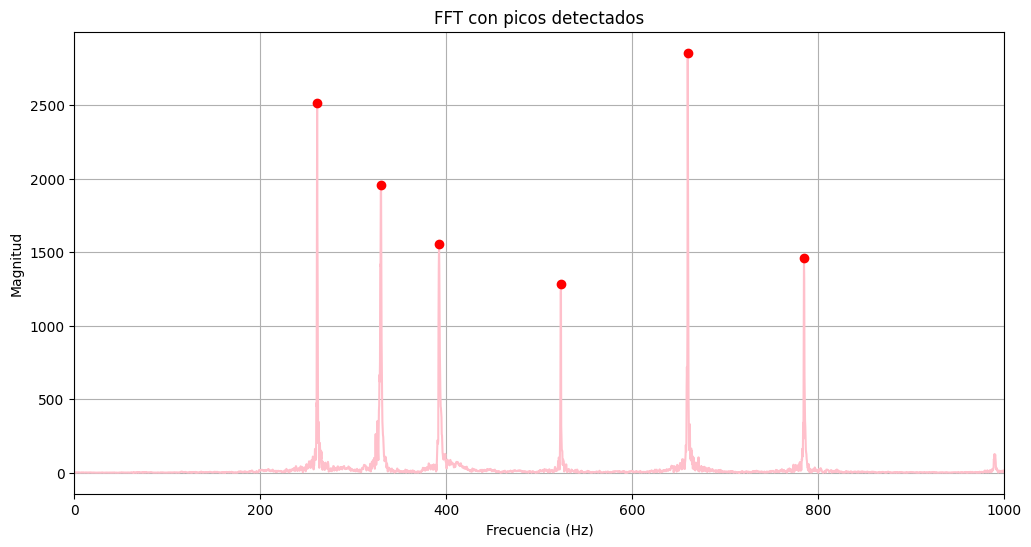

In [9]:
# Detectar picos
picos, propiedades = find_peaks(
    yf,
    height=np.max(yf)*0.1,   # umbral
    distance=20                    # separación mínima
)

# Graficar
plt.figure(figsize=(12,6))
plt.plot(xf, yf , c= "pink")
plt.plot(xf[picos], yf[picos], "o" , c = "red")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.title("FFT con picos detectados")
plt.xlim(0, 1000)
plt.grid()
plt.show()

In [10]:
Picos_NP = xf[picos]

In [11]:
indice_max = np.argmax(yf) # Índice del pico máximo
frecuencia_fundamental = xf[indice_max] # Frecuencia fundamental

print(f"Frecuencia fundamental: {frecuencia_fundamental:.2f} Hz")

Frecuencia fundamental: 659.48 Hz


La frecuencia detectada con mayor magnitud fue 659.48Hz, que corresponde a la nota Mi en afinacion estandar.

#FT(X,Y)

In [12]:
def g(t,w):
    return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)


def FT(x,y,w1,w2):
 #Interpolate f(t) to integrate
  f_interp = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
  ft = lambda t: f_interp(t)

    # range of t to integrate
  t = np.linspace(x.min(), x.max(), 400)

  # FRECUENCIES spectrum to looking for peaks
  w = np.linspace(w1,w2,500)

  df = []
  for i in range(len(w)):
        # The integration range should also match the signal's duration
        ARew = integrate.quad(lambda t_val: ft(t_val)*g(t_val,w[i]).real, t.min(), t.max())[0]
        AImw = integrate.quad(lambda t_val: ft(t_val)*g(t_val,w[i]).imag, t.min(), t.max())[0]
        AMP = np.sqrt(ARew**2 + AImw**2)
        ANG = np.arctan2(AImw, ARew)
        df.append([w[i], ARew, AImw, AMP, ANG])

    # DataFrame
  df = pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw', 'AMP', 'ANG'])
  print("La frecuencia fundamental de la señal es:" , df.w[df.AMP.idxmax()])
  return df

In [13]:
signal, sr = librosa.load('Nota_CM_piano.mp3', sr=None)
X = np.linspace(0, len(signal)/sr, len(signal))
df = FT(X,signal,0,1000)

/tmp/ipykernel_2239/1458393139.py:19: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  ARew = integrate.quad(lambda t_val: ft(t_val)*g(t_val,w[i]).real, t.min(), t.max())[0]
/tmp/ipykernel_2239/1458393139.py:20: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  AImw = integrate.quad(lambda t_val: ft(t_val)*g(t_val,w[i]).imag, t.min(), t.max())[0]
/tmp/ipykernel_2239/1458393139.py:20: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  AImw = integrate.quad(lambda t_val: ft(t_val)*g(t_val,w[i]).imag, t.min(), t.max())[0]
/tmp/i

La frecuencia fundamental de la señal es: 673.3466933867735


/tmp/ipykernel_2239/2371928228.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


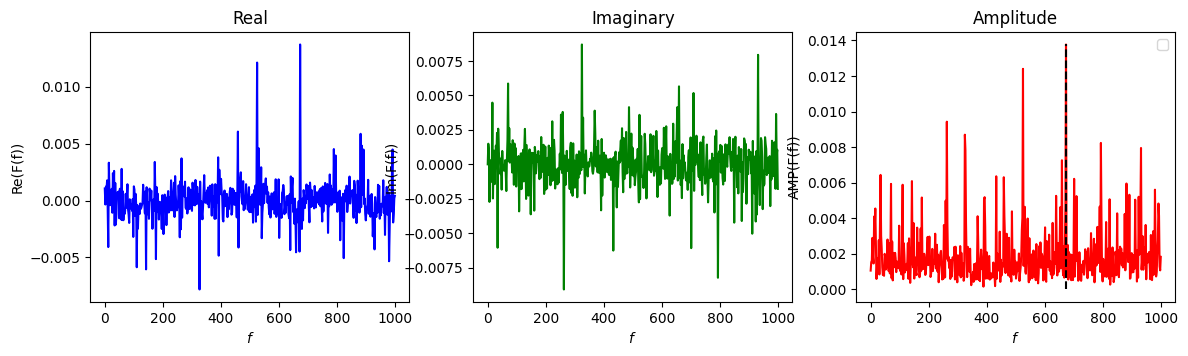

In [14]:
plt.figure(figsize=(14,3.5))

######## REAL ###########
plt.subplot(1,3,1)
plt.plot(df.w, df.ReTw,'b-')
plt.title('Real')
plt.xlabel('$f$')
plt.ylabel('Re(F(f))')

######### IMAG ##########
plt.subplot(1,3,2)
plt.plot(df.w, df.ImTw,'g-')
plt.title('Imaginary')
plt.xlabel('$f$')
plt.ylabel('Im(F(f))')

Vmax = df.w[df.AMP.idxmax()]
######### AMP ##########
plt.subplot(1,3,3)
plt.plot(df.w, df.AMP,'r-')
plt.vlines(Vmax, 0, max(df.AMP), 'k', '--')
plt.title('Amplitude')
plt.xlabel('$f$')
plt.ylabel('AMP(F(f))')
plt.legend(loc='best')
plt.show()

/tmp/ipykernel_2239/110452851.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(df.w, df.AMP,'r-', c="pink")
/tmp/ipykernel_2239/110452851.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


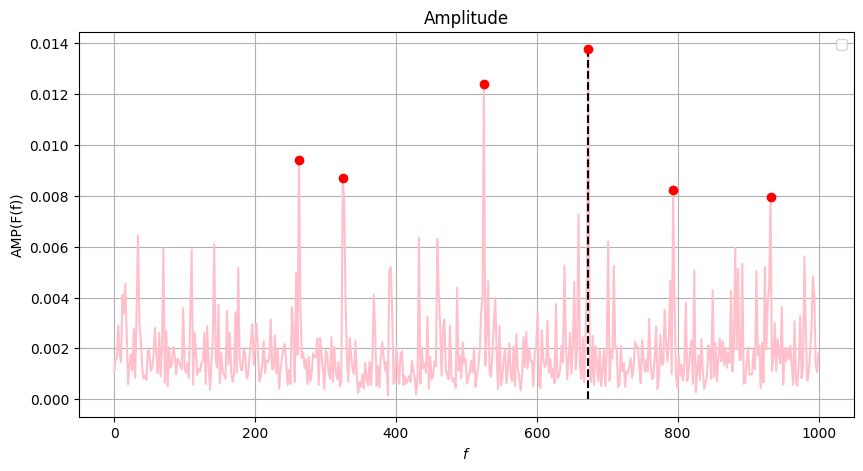

In [26]:
# Detectar picos
picos, propiedades = find_peaks(
    df.AMP,
    height=np.max(df.AMP)*0.48, #para disminuir ruido
    distance=20
)
Picos_FT = df.w[picos]

plt.figure(figsize=(10,5))

plt.plot(df.w, df.AMP,'r-', c="pink")
plt.vlines(Vmax, 0, max(df.AMP), 'k', '--')
plt.plot(df.w[picos], df.AMP[picos], "o" , c = "red")
plt.title('Amplitude')
plt.xlabel('$f$')
plt.ylabel('AMP(F(f))')
plt.legend(loc='best')
plt.grid()
plt.show()

La solucion sin usar las librerias Scypy y Numpy es menos eficiente. Genera mayor ruido en la transformada de Fourier y toma mayor tiempo computacionalmente. El valor de frecuencia con mayor magnitud, que corresponde a la frecuencia natural,depende de las iteraciones que se usen en el for del codigo determinado por la cantidad de numeros que se tomen en el intervalo de las frecuencias. Es un resultado poco satisfactorio. Comparamos entonces en terminos de las frecuencias relevantes:

In [27]:
print(f"""Frecuencias relevantes del sonido:
Np y Sp : {Picos_NP}
FT(X,Y) :  {np.array(Picos_FT)}""")

Frecuencias relevantes del sonido:
Np y Sp : [ 261.00852273  329.74076705  392.09280303  523.17708333  659.48153409
  784.47561553 1177.72845644 1576.2014678  1971.484375   1990.04498106
 2110.68892045 2666.05705492]
FT(X,Y) :  [262.5250501  324.6492986  525.0501002  673.34669339 793.58717435
 931.86372745]


Observamos que las frecuencias obtenidas en ambos metodos son similares. La primera frecuencia detectada por ambos es bastante similar y se le atribuye a la nota Do Mayor.